ELG 5376

In [1]:
import numpy as np  
import matplotlib.pyplot as plt  
import scipy.io.wavfile as wav
import numpy as np
import soundfile as sf
from scipy.signal import convolve

In [5]:

def beamform_mvdr(freq, angles, fft_size, fs = 16000):  
    # Beamform using the MVDR beamformer  
    num_mics = 3  # number of microphones  
    c = 343  # speed of sound  
    mic_spacing = 0.25  # microphone spacing  
    freq2 = 2 * np.pi * freq/fft_size *fs
    # Compute the steering vectors  
    sv1 = np.exp(np.arange(num_mics) * np.cos(np.deg2rad(angles[0])) * -1j *  freq2 * mic_spacing / c).reshape(3,1)  
    sv2 = np.exp(np.arange(num_mics) * np.cos(np.deg2rad(angles[1])) * -1j  * freq2 * mic_spacing / c).reshape(3,1)  
    sv3 = np.exp(np.arange(num_mics) * np.cos(np.deg2rad(angles[2])) * -1j *  freq2 * mic_spacing / c).reshape(3,1)  

    # gamma_psn = (sv2 @ sv2.conj().T) + (sv3 @ sv3.conj().T) 
    
    gamma_psn = np.matmul(sv2 , sv2.conj().T) + np.matmul(sv3, sv3.conj().T)
    gamma_psn += np.eye(num_mics) * 1e-2  # Regularization term 
    # print(gamma_psn) 
    tmp = np.linalg.solve(gamma_psn, sv1)  
    h_mvdr = np.squeeze(tmp / (sv1.conj().T @ tmp))  # Ensure it's a 1D array  
    return h_mvdr 

# Set2

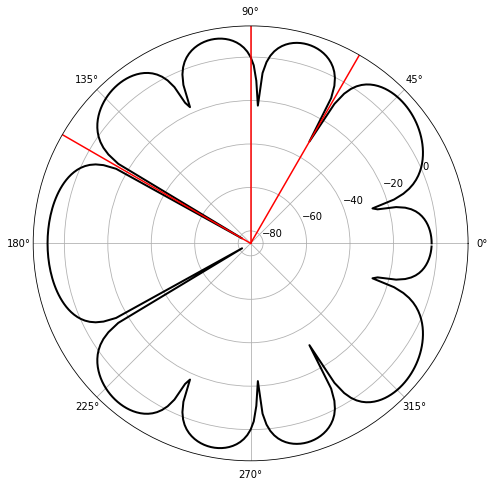

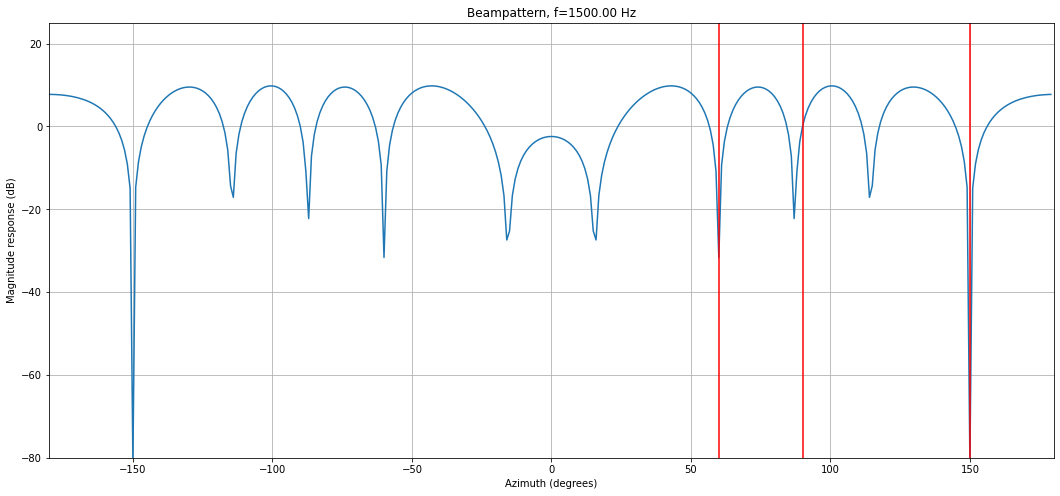

img3 0.0 img2 0.0 img1 0.0
re3 0.34935818763032767 re2 0.37496883972176503 re1 0.34935818763032767


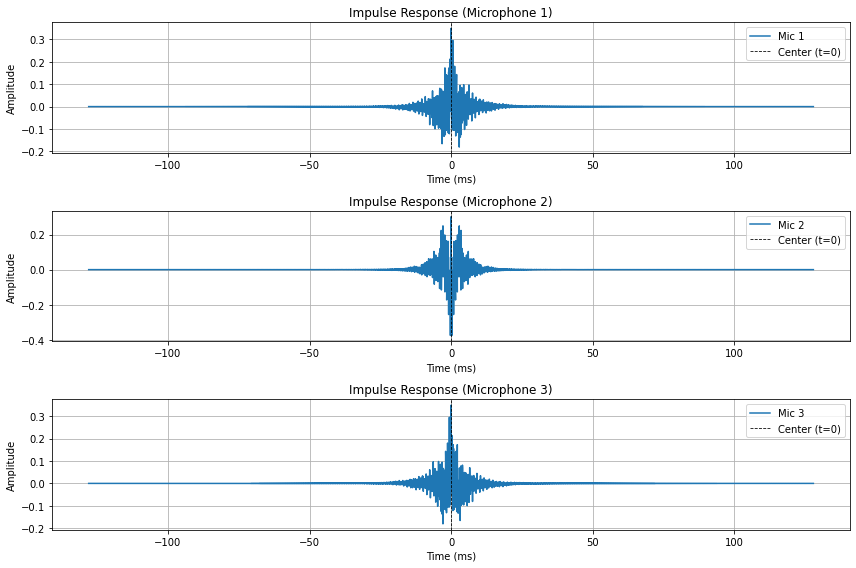

Processed signal saved as 'filtered_signal_improved_Set2.wav'


In [24]:
# Constants  
fs = 16000  # Sampling frequency  
num_mics = 3  # Number of microphones  
mic_spacing = 0.25  # Microphone spacing (meters)  
v_sound = 343  # Speed of sound (m/s)  

# Test parameters  
desired_angle = 90  # Desired angle of arrival  
ps_angle1 = 150  # Angle of arrival of point source 1  
ps_angle2 = 60  # Angle of arrival of point source 2  

fft_size = 4096 

# Initialize weight matrix  
Wbf = np.zeros((num_mics, fft_size), dtype=complex)  

for fr in range(-fft_size // 2, fft_size // 2):  
    index = fr + (fft_size // 2)  # Corrected index calculation  
    Wbf[:, index] = beamform_mvdr(fr, [desired_angle, ps_angle1, ps_angle2],fft_size )  
    # print( Wbf[:, index].size)

Wbf = np.fft.fftshift(Wbf, axes=1)  
# Nyquist frequency  
# f_nyquist = fs // 2  
# Wbf[:, f_nyquist] = np.real(Wbf[:, f_nyquist])  
# Wbf[:, -1] = np.real(Wbf[:, -1])  

# Compute and plot beampattern at specific frequency  
f_for_beampattern = 1500.0  # Hz  
bin_for_beampattern = 1 + round(f_for_beampattern / fs * fft_size)  
nb_angles = 360  
beampattern = np.zeros(nb_angles)  

for angle_index in range(nb_angles):  
    taus = (np.arange(num_mics) * mic_spacing / v_sound * np.cos(angle_index / nb_angles * 2 * np.pi))  
    D_propag_freq = np.exp(-1j * 2 * np.pi * f_for_beampattern * taus)  
    beampattern[angle_index] = abs(np.dot(np.conj(Wbf[:, bin_for_beampattern]), D_propag_freq))**2  

# Polar beampattern  
plt.figure(figsize=(12, 8))  # Polar beampattern  
angles_for_beampattern = np.linspace(0, 360, nb_angles, endpoint=False)  
plt.polar(np.deg2rad(angles_for_beampattern), 10 * np.log10(beampattern), color='k', linestyle='-', linewidth=2)  
plt.axvline(np.deg2rad(60), color = 'red')
plt.axvline(np.deg2rad(90), color = 'red')
plt.axvline(np.deg2rad(150), color = 'red')


# Rectangular beampattern  
plt.figure(figsize=(18, 8))  # Rectangular beampattern  
angles_for_beampattern = np.linspace(-180, 180, nb_angles, endpoint=False)  
plt.plot(angles_for_beampattern, np.clip(np.fft.fftshift(10 * np.log10(beampattern)), -100, None))  
plt.grid(which='both')  
plt.axis([-180, 180, -80, 25])  
plt.ylabel('Magnitude response (dB)')  
plt.xlabel('Azimuth (degrees)')  
plt.axvline(60, color = 'red')
plt.axvline(x = 90, color = 'red')
plt.axvline(x = 150, color = 'red')
plt.title(f'Beampattern, f={f_for_beampattern:.2f} Hz')  
plt.show()  

########################################
# Constants
fs = 16000  # Sampling frequency (samples per second)

# Compute impulse responses by applying IFFT to each row of Wbf
impulse_responses = np.fft.ifft(np.conj(Wbf), axis=1).real  # Take the real part of the IFFT

# Generate symmetric time indices in milliseconds
num_samples = impulse_responses.shape[1]
half_samples = num_samples // 2
time = np.linspace(-half_samples, half_samples - 1, num_samples) / fs * 1000  # Time in milliseconds


re=np.max(np.abs(np.real(impulse_responses[0,:])))
im=np.max(np.abs(np.imag(impulse_responses[0,:])))
re2=np.max(np.abs(np.real(impulse_responses[1,:])))
im2=np.max(np.abs(np.imag(impulse_responses[1,:])))
re3=np.max(np.abs(np.real(impulse_responses[2,:])))
im3=np.max(np.abs(np.imag(impulse_responses[2,:])))

print("img3",im3, "img2",im2, "img1", im )
print("re3",re3, "re2",re2, "re1", re )


# Shift impulse responses for symmetry around 0
impulse_responses = np.fft.fftshift(impulse_responses, axes=1)

# Plot impulse responses separately for each microphone
num_mics = impulse_responses.shape[0]
plt.figure(figsize=(12, 8))
for mic in range(num_mics):
    plt.subplot(num_mics, 1, mic + 1)  # Separate subplot for each microphone
    plt.plot(time, impulse_responses[mic], label=f'Mic {mic + 1}')
    plt.title(f'Impulse Response (Microphone {mic + 1})')
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8, label='Center (t=0)')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()



###############################

fs, x1 = wav.read("H:/DSP_project/mixture1_set2.wav")  # Sampling frequency and signal 1
_, x2 = wav.read("H:/DSP_project/mixture2_set2.wav")  # Sampling frequency and signal 1
_, x3 = wav.read("H:/DSP_project/mixture3_set2.wav")  # Sampling frequency and signal 1

filtered_signal = convolve(x1,impulse_responses[0],"same") + convolve(x2,impulse_responses[1],"same") + convolve(x3,impulse_responses[2],"same")


# Ensure filtered_signal is real
real_filtered_signal = np.real(filtered_signal)

# Optionally, normalize the signal to fit within the valid range of int16
normalized_signal = real_filtered_signal / np.max(np.abs(real_filtered_signal))
normalized_signal = (normalized_signal * 32767).astype(np.int16)  # Scale to int16 range

# Save as .wav file
sf.write("filtered_signal_improved_Set2_xx.wav", normalized_signal, fs)
print("Processed signal saved as 'filtered_signal_improved_Set2.wav'")

################################

# Magnitute response set 2

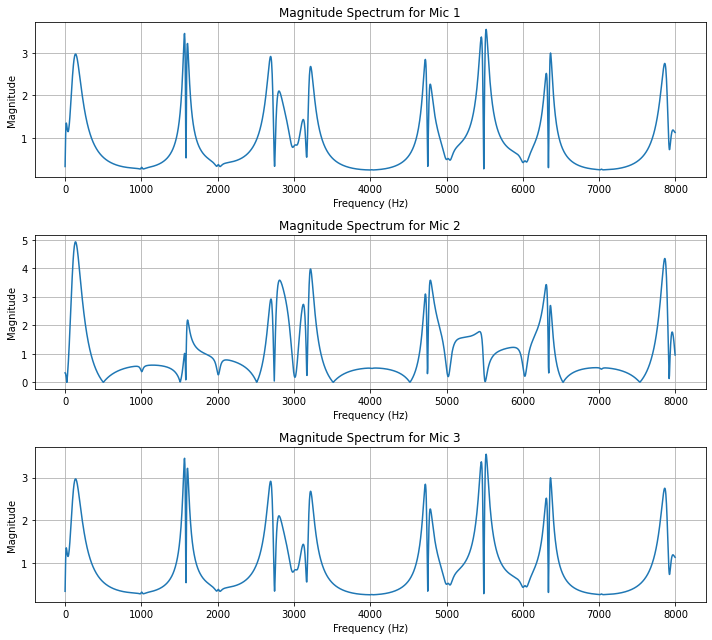

In [3]:
# Constants
fs = 16000  # Sampling frequency

# Compute FFT of impulse responses
fft_responses = np.fft.fft(impulse_responses, axis=1)
frequencies = np.fft.fftfreq(impulse_responses.shape[1], d=1/fs)  # Frequency bins

# Create subplots for each microphone
num_mics = fft_responses.shape[0]
plt.figure(figsize=(10, 3 * num_mics))  # Adjust figure size based on the number of microphones

for mic in range(num_mics):
    plt.subplot(num_mics, 1, mic + 1)
    plt.plot(frequencies[:len(frequencies)//2],  # Positive frequencies
             np.abs(fft_responses[mic, :len(frequencies)//2]))
    plt.title(f'Magnitude Spectrum for Mic {mic + 1}')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(True)

plt.tight_layout()
plt.show()


#  Beam Pattern Set 1

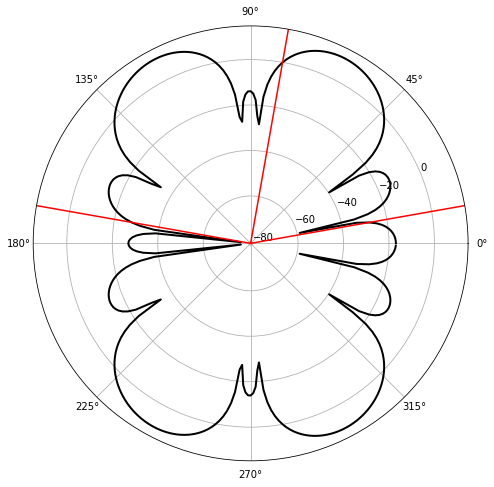

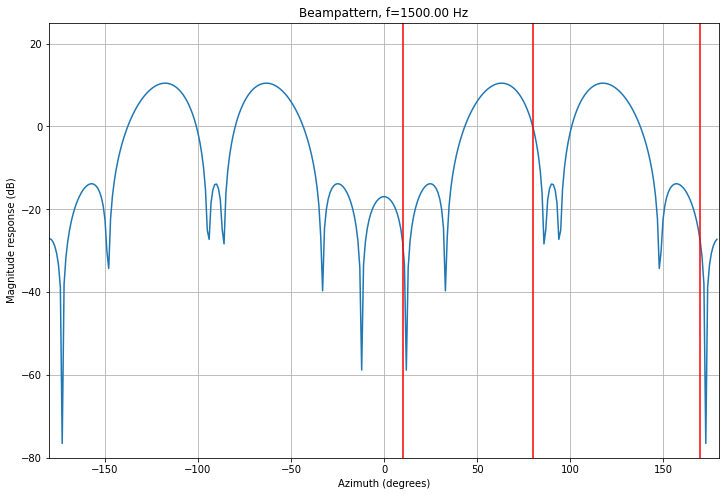

img3 0.0 img2 0.0 img1 0.0
re3 0.3360490430475549 re2 0.3222784750877915 re1 0.33864637456182645


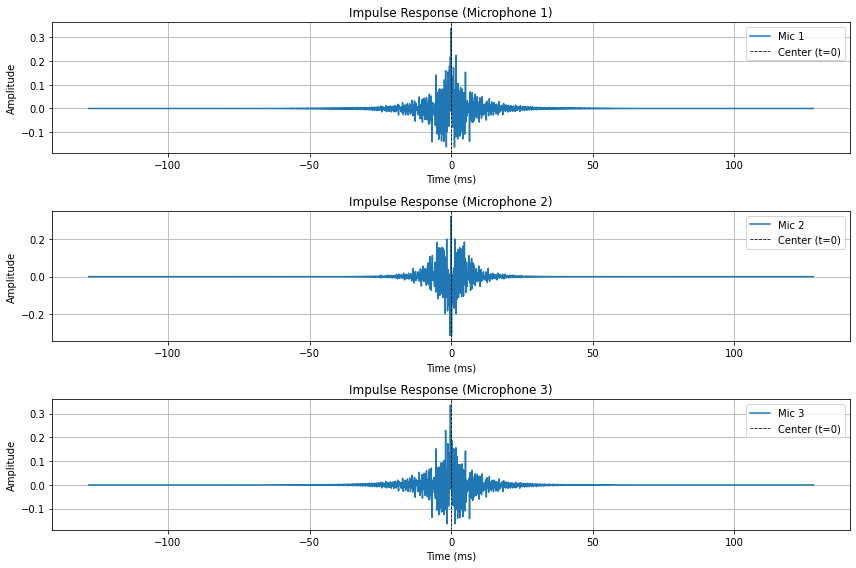

Processed signal saved as 'filtered_signal_improved_Set1_xx.wav'


In [25]:

# Constants  
fs = 16000  # Sampling frequency  
num_mics = 3  # Number of microphones  
mic_spacing = 0.25  # Microphone spacing (meters)  
v_sound = 343  # Speed of sound (m/s)  

# Test parameters  
desired_angle = 80  # Desired angle of arrival  
ps_angle1 = 10  # Angle of arrival of point source 1  
ps_angle2 = 170  # Angle of arrival of point source 2  

fft_size = 4096 

# Initialize weight matrix  
Wbf = np.zeros((num_mics, fft_size), dtype=complex)  

for fr in range(-fft_size // 2, fft_size // 2):  
    index = fr + (fft_size // 2)  # Corrected index calculation  
    Wbf[:, index] = beamform_mvdr(fr, [desired_angle, ps_angle1, ps_angle2],fft_size )  
    # print( Wbf[:, index].size)

Wbf = np.fft.fftshift(Wbf, axes=1)  
# Nyquist frequency  
# f_nyquist = fs // 2  
# Wbf[:, f_nyquist] = np.real(Wbf[:, f_nyquist])  
# Wbf[:, -1] = np.real(Wbf[:, -1])  

# Compute and plot beampattern at specific frequency  
f_for_beampattern = 1500.0  # Hz  
bin_for_beampattern = 1 + round(f_for_beampattern / fs * fft_size)  
nb_angles = 360  
beampattern = np.zeros(nb_angles)  

for angle_index in range(nb_angles):  
    taus = (np.arange(num_mics) * mic_spacing / v_sound * np.cos(angle_index / nb_angles * 2 * np.pi))  
    D_propag_freq = np.exp(-1j * 2 * np.pi * f_for_beampattern * taus)  
    beampattern[angle_index] = abs(np.dot(np.conj(Wbf[:, bin_for_beampattern]), D_propag_freq))**2  

# Polar beampattern  
plt.figure(figsize=(12, 8))  # Polar beampattern  
angles_for_beampattern = np.linspace(0, 360, nb_angles, endpoint=False)  
plt.polar(np.deg2rad(angles_for_beampattern), 10 * np.log10(beampattern), color='k', linestyle='-', linewidth=2)  
plt.axvline(np.deg2rad(80), color = 'red')
plt.axvline(np.deg2rad(10), color = 'red')
plt.axvline(np.deg2rad(170), color = 'red')


# Rectangular beampattern  
plt.figure(figsize=(12, 8))  # Rectangular beampattern  
angles_for_beampattern = np.linspace(-180, 180, nb_angles, endpoint=False)  
plt.plot(angles_for_beampattern, np.clip(np.fft.fftshift(10 * np.log10(beampattern)), -100, None))  
plt.grid(which='both')  
plt.axis([-180, 180, -80, 25])  
plt.ylabel('Magnitude response (dB)')  
plt.xlabel('Azimuth (degrees)')  
plt.axvline(80, color = 'red')
plt.axvline(x = 10, color = 'red')
plt.axvline(x = 170, color = 'red')

plt.title(f'Beampattern, f={f_for_beampattern:.2f} Hz')  
plt.show()  

########################################
# Constants
fs = 16000  # Sampling frequency (samples per second)

# Compute impulse responses by applying IFFT to each row of Wbf
impulse_responses = np.fft.ifft(np.conj(Wbf), axis=1).real  # Take the real part of the IFFT

# Generate symmetric time indices in milliseconds
num_samples = impulse_responses.shape[1]
half_samples = num_samples // 2
time = np.linspace(-half_samples, half_samples - 1, num_samples) / fs * 1000  # Time in milliseconds


re=np.max(np.abs(np.real(impulse_responses[0,:])))
im=np.max(np.abs(np.imag(impulse_responses[0,:])))
re2=np.max(np.abs(np.real(impulse_responses[1,:])))
im2=np.max(np.abs(np.imag(impulse_responses[1,:])))
re3=np.max(np.abs(np.real(impulse_responses[2,:])))
im3=np.max(np.abs(np.imag(impulse_responses[2,:])))

print("img3",im3, "img2",im2, "img1", im )
print("re3",re3, "re2",re2, "re1", re )


# Shift impulse responses for symmetry around 0
impulse_responses = np.fft.fftshift(impulse_responses, axes=1)

# Plot impulse responses separately for each microphone
num_mics = impulse_responses.shape[0]
plt.figure(figsize=(12, 8))
for mic in range(num_mics):
    plt.subplot(num_mics, 1, mic + 1)  # Separate subplot for each microphone
    plt.plot(time, impulse_responses[mic], label=f'Mic {mic + 1}')
    plt.title(f'Impulse Response (Microphone {mic + 1})')
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8, label='Center (t=0)')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()



###############################

fs, x1 = wav.read("H:/DSP_project/mixture1.wav")  # Sampling frequency and signal 1
_, x2 = wav.read("H:/DSP_project/mixture2.wav")  # Sampling frequency and signal 1
_, x3 = wav.read("H:/DSP_project/mixture3.wav")  # Sampling frequency and signal 1


filtered_signal = convolve(x1,impulse_responses[0],"same") + convolve(x2,impulse_responses[1],"same") + convolve(x3,impulse_responses[2],"same")



# Ensure filtered_signal is real
real_filtered_signal = np.real(filtered_signal)

# Optionally, normalize the signal to fit within the valid range of int16
normalized_signal = real_filtered_signal / np.max(np.abs(real_filtered_signal))
normalized_signal = (normalized_signal * 32767).astype(np.int16)  # Scale to int16 range

# Save as .wav file
sf.write("filtered_signal_improved_Set1_xx.wav", normalized_signal, fs)
print("Processed signal saved as 'filtered_signal_improved_Set1_xx.wav'")

################################

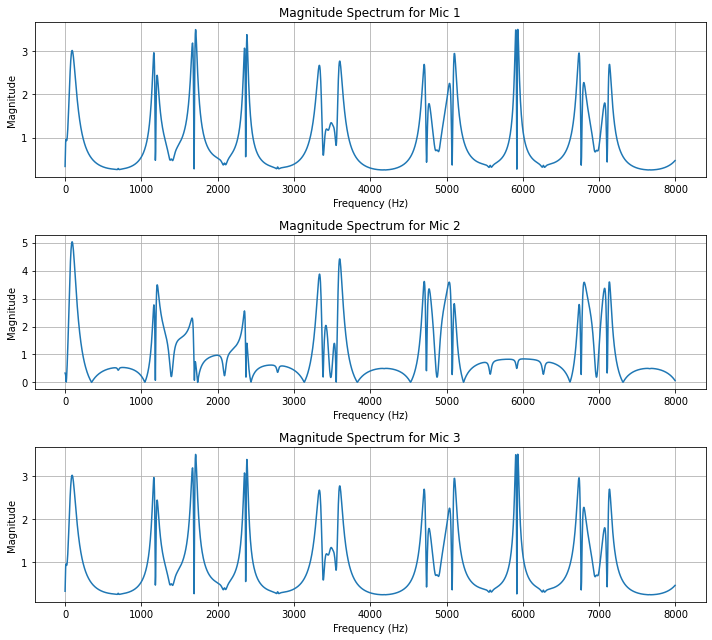

In [26]:
# Constants
fs = 16000  # Sampling frequency

# Compute FFT of impulse responses
fft_responses = np.fft.fft(impulse_responses, axis=1)
frequencies = np.fft.fftfreq(impulse_responses.shape[1], d=1/fs)  # Frequency bins

# Create subplots for each microphone
num_mics = fft_responses.shape[0]
plt.figure(figsize=(10, 3 * num_mics))  # Adjust figure size based on the number of microphones

for mic in range(num_mics):
    plt.subplot(num_mics, 1, mic + 1)
    plt.plot(frequencies[:len(frequencies)//2],  # Positive frequencies
             np.abs(fft_responses[mic, :len(frequencies)//2]))
    plt.title(f'Magnitude Spectrum for Mic {mic + 1}')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(True)

plt.tight_layout()
plt.show()
